# Module import

In [59]:
from netCDF4 import Dataset                             
import numpy as np            

import matplotlib.pyplot as plt           
import matplotlib.colors as mcolors              
import cartopy.crs as ccrs                              
import cartopy.feature as cfeature     
import cartopy.io.shapereader as shpreader

import sys
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timedelta


import os
from scipy.ndimage import gaussian_filter
from matplotlib.colors import ListedColormap

# Choose nowcast origin and lead time (in hour)

In [60]:
year = "2024"
month = "09"
day = "27"
hour = "17"
minute = "15"

# Configurations

In [61]:
DISPLAY_LON_MIN = -18.5
DISPLAY_LON_MAX = -4.45
DISPLAY_LAT_MIN = 5.1
DISPLAY_LAT_MAX = 19.5

# Ground truth 

In [62]:
def update_hour(date_dict, hours_to_add, minutes_to_add):
    """
    Add hours and minutes to a datetime dictionary and return the updated dict and a generated file path.

    Args:
        date_dict     (dict): Keys: 'year', 'month', 'day', 'hour', 'minute' as strings, e.g. "01", "23"
        hours_to_add   (int): Number of hours to add.
        minutes_to_add (int): Number of minutes to add.

    Returns:
        tuple:
            - dict: Updated datetime dictionary with all fields as zero-padded strings.
            - str: File path in the format YYYY/MM/YYYYMMDDHHMM.nc
    """
    # Parse the original time
    time_obj = datetime(
        int(date_dict["year"]),
        int(date_dict["month"]),
        int(date_dict["day"]),
        int(date_dict["hour"]),
        int(date_dict["minute"])
    )

    # Add hours
    updated = time_obj + timedelta(hours=hours_to_add, minutes=minutes_to_add)

    # Format updated dictionary
    new_date_dict = {
        "year":   f"{updated.year:04d}",
        "month":  f"{updated.month:02d}",
        "day":    f"{updated.day:02d}",
        "hour":   f"{updated.hour:02d}",
        "minute": f"{updated.minute:02d}"
    }

    # Generate file path
    file_path = f"{new_date_dict['year']}/{new_date_dict['month']}/{new_date_dict['year']}{new_date_dict['month']}{new_date_dict['day']}{new_date_dict['hour']}{new_date_dict['minute']}.nc"

    return {'time': new_date_dict, 'path': file_path}

In [63]:
def load_wavelet_dataset(year, month, day, hour, minute, lead_time):
    
    nowcast_origin = {
        "year":   year,
        "month":  month,
        "day":    day,
        "hour":   hour,
        "minute": minute,
    }

    nowcast_lt = update_hour(nowcast_origin, hours_to_add=lead_time, minutes_to_add=0)["time"]

    path_core = f"/gws/ssde/j25b/cocoon/SSA_domain/ch9_wavelet/{nowcast_lt['year']}/{nowcast_lt['month']}"
    file = f"{path_core}/{nowcast_lt['year']}{nowcast_lt['month']}{nowcast_lt['day']}{nowcast_lt['hour']}{nowcast_lt['minute']}.nc"
    return Dataset(file, mode='r')["cores"]

In [64]:
y_min, y_max = 1403, 1914
x_min, x_max = 66, 577

In [65]:
ground_truth_t1 = load_wavelet_dataset(year, month, day, hour, minute, 1)[0, y_min:y_max+1, x_min:x_max+1] != 0
ground_truth_t3 = load_wavelet_dataset(year, month, day, hour, minute, 3)[0, y_min:y_max+1, x_min:x_max+1] != 0
ground_truth_t6 = load_wavelet_dataset(year, month, day, hour, minute, 6)[0, y_min:y_max+1, x_min:x_max+1] != 0

In [66]:
geodata = np.load("/gws/ssde/j25b/cocoon/SSA_domain/lat_lon_2268_2080.npz")
lons = geodata["lon"][y_min:y_max+1, x_min:x_max+1]
lats = geodata["lat"][y_min:y_max+1, x_min:x_max+1]

# Double checking NFLICS

In [67]:
def load_NFLICS_nowcast(year, month, day, hour, minute, lead_time):
    NFLICS_BaseDir = f"/gws/ssde/j25b/swift/nflics_nowcasts/{year}/{month}/{day}/{hour}{minute}"
    file = f"{NFLICS_BaseDir}/Nowcast_{year}{month}{day}{hour}{minute}_000.nc" 
    data = Dataset(file, mode='r')["Probability"][lead_time, :, :]
    return data

In [68]:
def compute_NFLICS_latlon(ny, nx, top, bottom, left, right):
    """
    Generate latitude and longitude grids for NFLICS nowcasts.

    Parameters
    ----------
    ny, nx : int
        Array shape (rows, columns) of the nowcast grid.
    top, bottom, left, right : float
        Domain boundaries in degrees (EPSG:4326).
    Returns
    -------
    NFLICS_lats, NFLICS_lons : np.ndarray
        2D latitude and longitude grids of shape (ny, nx).
    """
    # Derive pixel size dynamically to avoid mismatch
    dx = (right - left) / nx
    dy = (top - bottom) / ny

    # 1D coordinate arrays (pixel centres)
    lons_1d = left + (np.arange(nx) + 0.5) * dx
    lats_1d = top  - (np.arange(ny) + 0.5) * dy

    # 2D grids
    NFLICS_lons, NFLICS_lats = np.meshgrid(lons_1d, lats_1d)

    return NFLICS_lats, NFLICS_lons

# SADC domain
top, bottom, left, right = 19.99001, -2.018712, -23.0, 32.021806
ny, nx = 776, 1748


NFLICS_lats, NFLICS_lons = compute_NFLICS_latlon(ny, nx, top, bottom, left, right)

NFLICS_LON_MIN = np.min(NFLICS_lons)
NFLICS_LON_MAX = np.max(NFLICS_lons)
NFLICS_LAT_MIN = np.min(NFLICS_lats)
NFLICS_LAT_MAX = np.max(NFLICS_lats)

print(NFLICS_lats.shape, NFLICS_lons.shape)
print(f"Latitude range:  {NFLICS_LAT_MIN:.4f} → {NFLICS_LAT_MAX:.4f}")
print(f"Longitude range: {NFLICS_LON_MIN:.4f} → {NFLICS_LON_MAX:.4f}")

(776, 1748) (776, 1748)
Latitude range:  -2.0045 → 19.9758
Longitude range: -22.9843 → 32.0061


In [69]:
nflics = load_NFLICS_nowcast(year, month, day, hour, minute, 1)
nflics[nflics <= 0] = 0.0
nflics = nflics / 100
nflics = np.clip(nflics, 0.0, 1.0)

In [70]:
nflics.shape

(776, 1748)

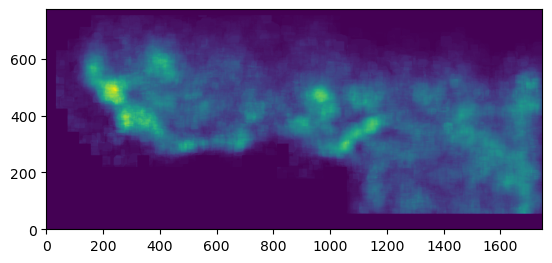

In [71]:
plt.imshow(nflics, origin="lower")
plt.show()

In [72]:
# WA domain bounds from Sam
lat_top = 19.99001
lat_bottom = -2.018712
lon_left = -23.0
lon_right = 32.021806

ny, nx = nflics.shape  # data is your nowcast 2D array

# latitude increases from bottom → top (south → north)
nflics_lats = np.linspace(lat_bottom, lat_top, ny)

# longitude increases from left → right (west → east)
nflics_lons = np.linspace(lon_left, lon_right, nx)

# create 2D meshgrid
nflics_lon2d, nflics_lat2d = np.meshgrid(nflics_lons, nflics_lats)


In [73]:
print(ny, nx)

776 1748


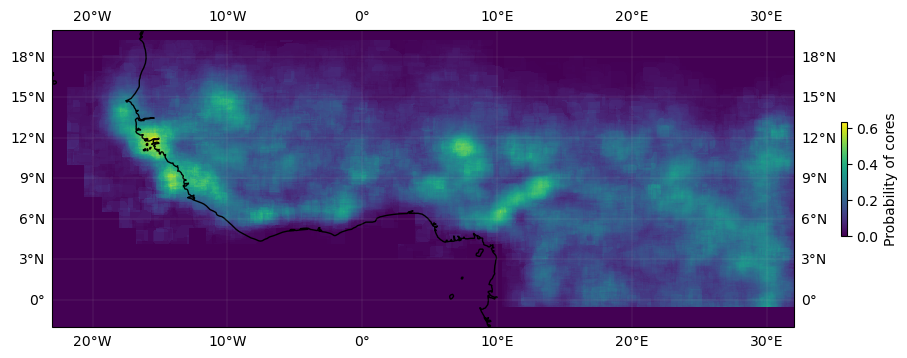

In [74]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# plot data
img = ax.pcolormesh(
    nflics_lon2d,
    nflics_lat2d,
    nflics,
    transform=ccrs.PlateCarree(),
    shading='auto'
)

# add coastlines and gridlines
ax.coastlines()
ax.set_extent([lon_left, lon_right, lat_bottom, lat_top], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linewidth=0.1)

plt.colorbar(img, ax=ax, label="Probability of cores", shrink=0.2)
plt.tight_layout()
plt.show()

# Cropped to Western Sahel

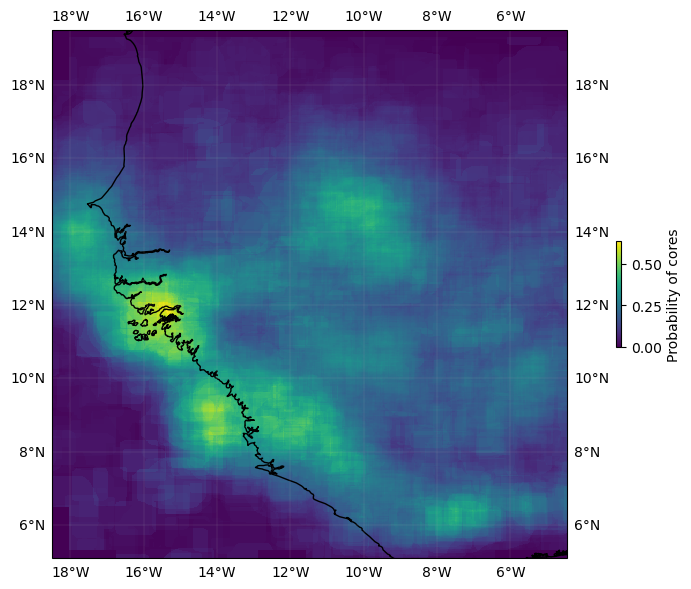

In [75]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# plot data
img = ax.pcolormesh(
    nflics_lon2d,
    nflics_lat2d,
    nflics,
    transform=ccrs.PlateCarree(),
    shading='auto'
)

# add coastlines and gridlines
ax.coastlines()
ax.set_extent(
        [DISPLAY_LON_MIN, DISPLAY_LON_MAX,
         DISPLAY_LAT_MIN, DISPLAY_LAT_MAX],
        crs=ccrs.PlateCarree()
    )
ax.gridlines(draw_labels=True, linewidth=0.1)
plt.colorbar(img, ax=ax, label="Probability of cores", shrink=0.2)
plt.tight_layout()
plt.show()

In [76]:
# latitude resolution (in degrees)
dlat = np.mean(np.diff(lats[:, 0]))

# longitude resolution (in degrees)
dlon = np.mean(np.diff(lons[0, :]))

print("Δlat =", dlat)
print("Δlon =", dlon)


Δlat = 0.028603515
Δlon = 0.028053867


In [77]:
print(np.nanmin(lats), np.nanmax(lats), np.nanmin(lons), np.nanmax(lons))

5.033134 19.701021 -19.831186 -4.1754155


# NFLICS plotting

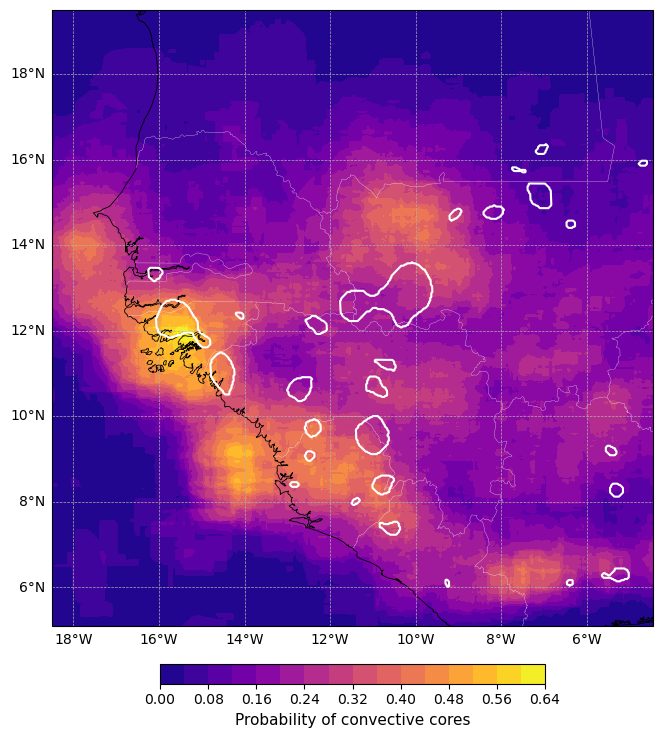

In [78]:
# create figure and axis
fig, ax = plt.subplots(
    1, 1, figsize=(8, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
    )

# set extent
ax.set_extent(
    [
        DISPLAY_LON_MIN,
        DISPLAY_LON_MAX,
        DISPLAY_LAT_MIN,
        DISPLAY_LAT_MAX
    ],
    crs=ccrs.PlateCarree()
)

# base map features
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='white', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.6)
ax.add_feature(cfeature.BORDERS, edgecolor='white', linewidth=0.2)

# western sahel gridlines
gl = ax.gridlines(
    draw_labels=True,
    alpha=1,
    linestyle='--',
    linewidth=0.5
)
gl.top_labels = False
gl.right_labels = False

# filled contours for nflics probability
im = ax.contourf(
    nflics_lon2d,
    nflics_lat2d,
    nflics,
    cmap='plasma',
    levels=20,
    vmin=0,
    vmax=np.max(nflics),
    transform=ccrs.PlateCarree(),
    zorder=1
)

# smooth binary ground truth
gt_smooth = gaussian_filter(ground_truth_t1.astype(float), sigma=0.4)

# red outline of observed storms
ax.contour(
    lons,
    lats,
    gt_smooth,
    levels=[0.5],
    colors='white',
    linewidths=1.5,
    transform=ccrs.PlateCarree(),
    zorder=5
)

# colourbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation='horizontal',
    shrink=0.5,
    pad=0.05
)
cbar.set_label('Probability of convective cores', fontsize=11)

# title
plt.tight_layout()
plt.show()


In [79]:
import numpy as np

# desired bounds
LAT_MIN = 5.033134
LAT_MAX = 19.701021
LON_MIN = -19.831186
LON_MAX = -4.1754155

# boolean mask selecting the desired region
mask = (
    (nflics_lat2d >= LAT_MIN) &
    (nflics_lat2d <= LAT_MAX) &
    (nflics_lon2d >= LON_MIN) &
    (nflics_lon2d <= LON_MAX)
)

# find bounding indices of mask
rows = np.where(mask.any(axis=1))[0]
cols = np.where(mask.any(axis=0))[0]

row_min, row_max = rows[0], rows[-1]
col_min, col_max = cols[0], cols[-1]

# crop arrays
nflics_crop = nflics[row_min:row_max+1, col_min:col_max+1]
lats_crop   = nflics_lat2d[row_min:row_max+1, col_min:col_max+1]
lons_crop   = nflics_lon2d[row_min:row_max+1, col_min:col_max+1]

print(lons_crop.shape)


(516, 497)


In [80]:
print(row_min, row_max, col_min, col_max)

249 764 101 597


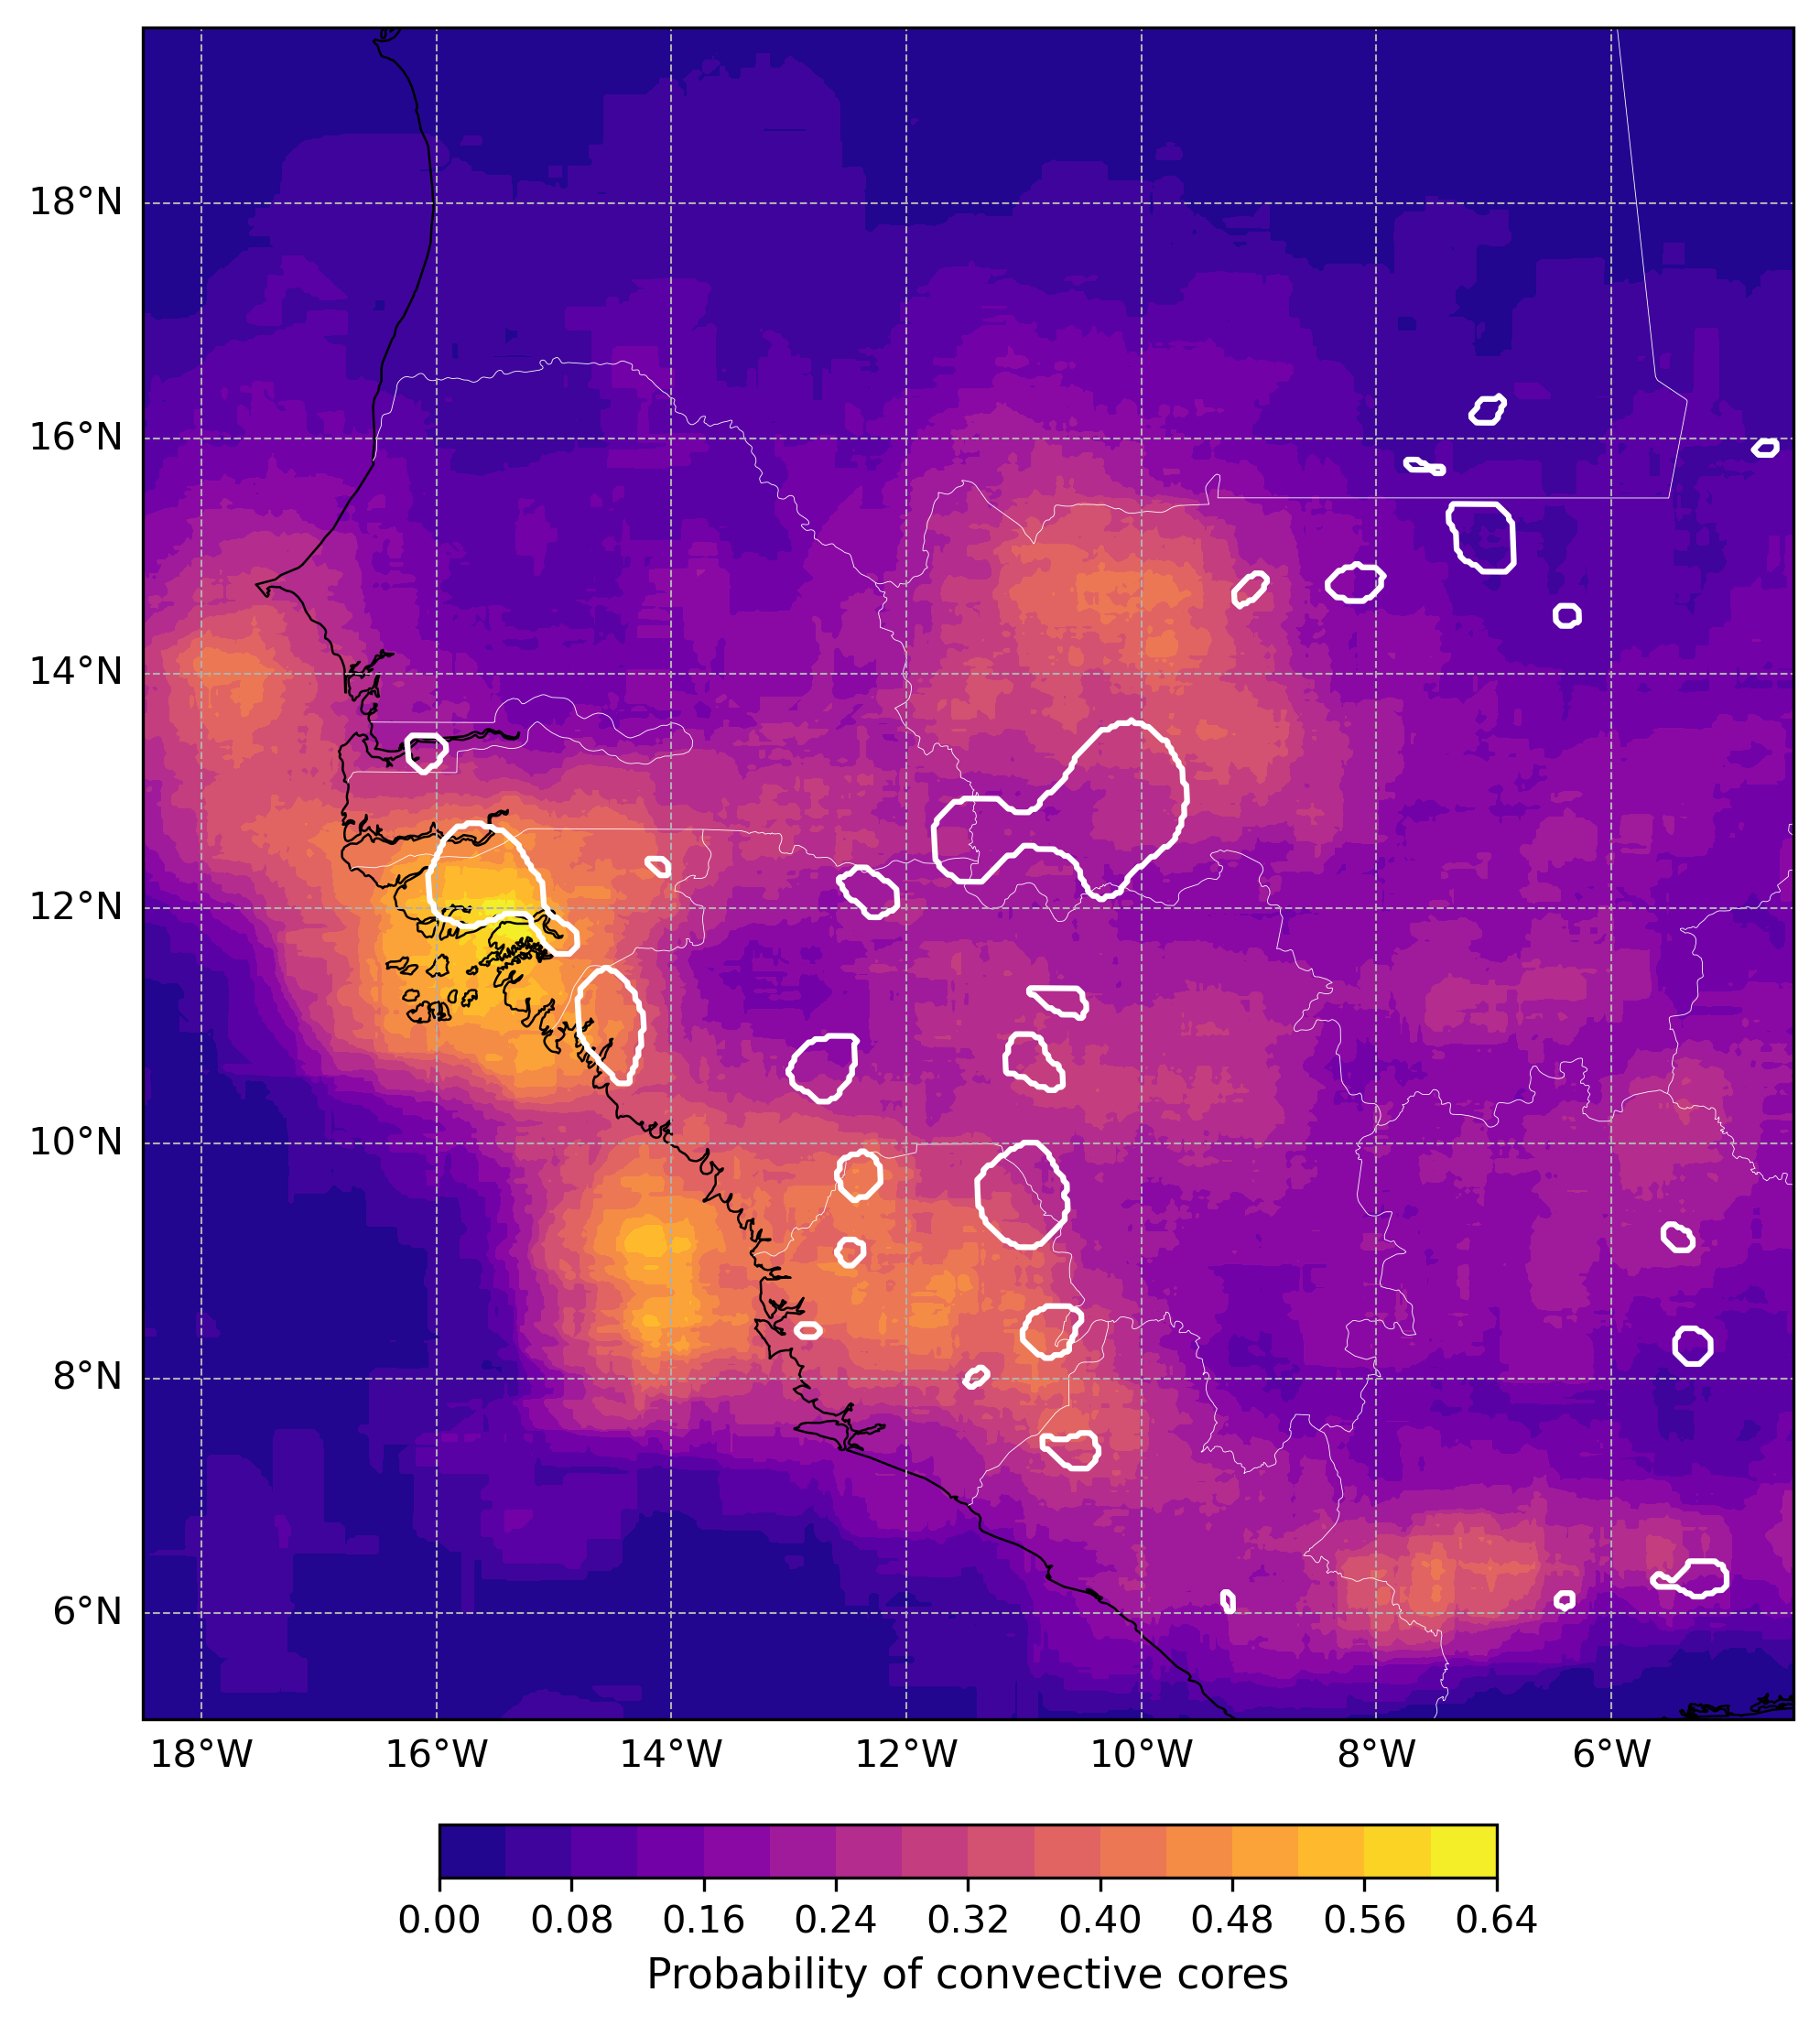

In [81]:
# create figure and axis
fig, ax = plt.subplots(
    1, 1, figsize=(8, 8),
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=300
)

# set extent
ax.set_extent(
    [
        DISPLAY_LON_MIN,
        DISPLAY_LON_MAX,
        DISPLAY_LAT_MIN,
        DISPLAY_LAT_MAX
    ],
    crs=ccrs.PlateCarree()
)

# base map features
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='white', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.6)
ax.add_feature(cfeature.BORDERS, edgecolor='white', linewidth=0.2)

# western sahel gridlines
gl = ax.gridlines(
    draw_labels=True,
    alpha=1,
    linestyle='--',
    linewidth=0.5
)
gl.top_labels = False
gl.right_labels = False

# filled contours for nflics probability
im = ax.contourf(
    lons_crop,
    lats_crop,
    nflics_crop,
    cmap='plasma',
    levels=20,
    vmin=0,
    vmax=np.max(nflics),
    transform=ccrs.PlateCarree(),
    zorder=1
)

# smooth binary ground truth
gt_smooth = gaussian_filter(ground_truth_t1.astype(float), sigma=0.4)

# red outline of observed storms
ax.contour(
    lons,
    lats,
    gt_smooth,
    levels=[0.5],
    colors='white',
    linewidths=1.5,
    transform=ccrs.PlateCarree(),
    zorder=5
)

# colourbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation='horizontal',
    shrink=0.5,
    pad=0.05
)
cbar.set_label('Probability of convective cores', fontsize=11)

# title
plt.tight_layout()
plt.show()


In [82]:
from scipy.ndimage import zoom

In [83]:
# target size
H, W = 512, 512

# current size
h, w = nflics_crop.shape

# zoom factors
zoom_h = H / h
zoom_w = W / w

# bilinear interpolation (order=1)
nflics_crop_512 = zoom(nflics_crop, (zoom_h, zoom_w), order=1)
lats_crop_512 = zoom(lats_crop, (zoom_h, zoom_w), order=1)
lons_crop_512 = zoom(lons_crop, (zoom_h, zoom_w), order=1)

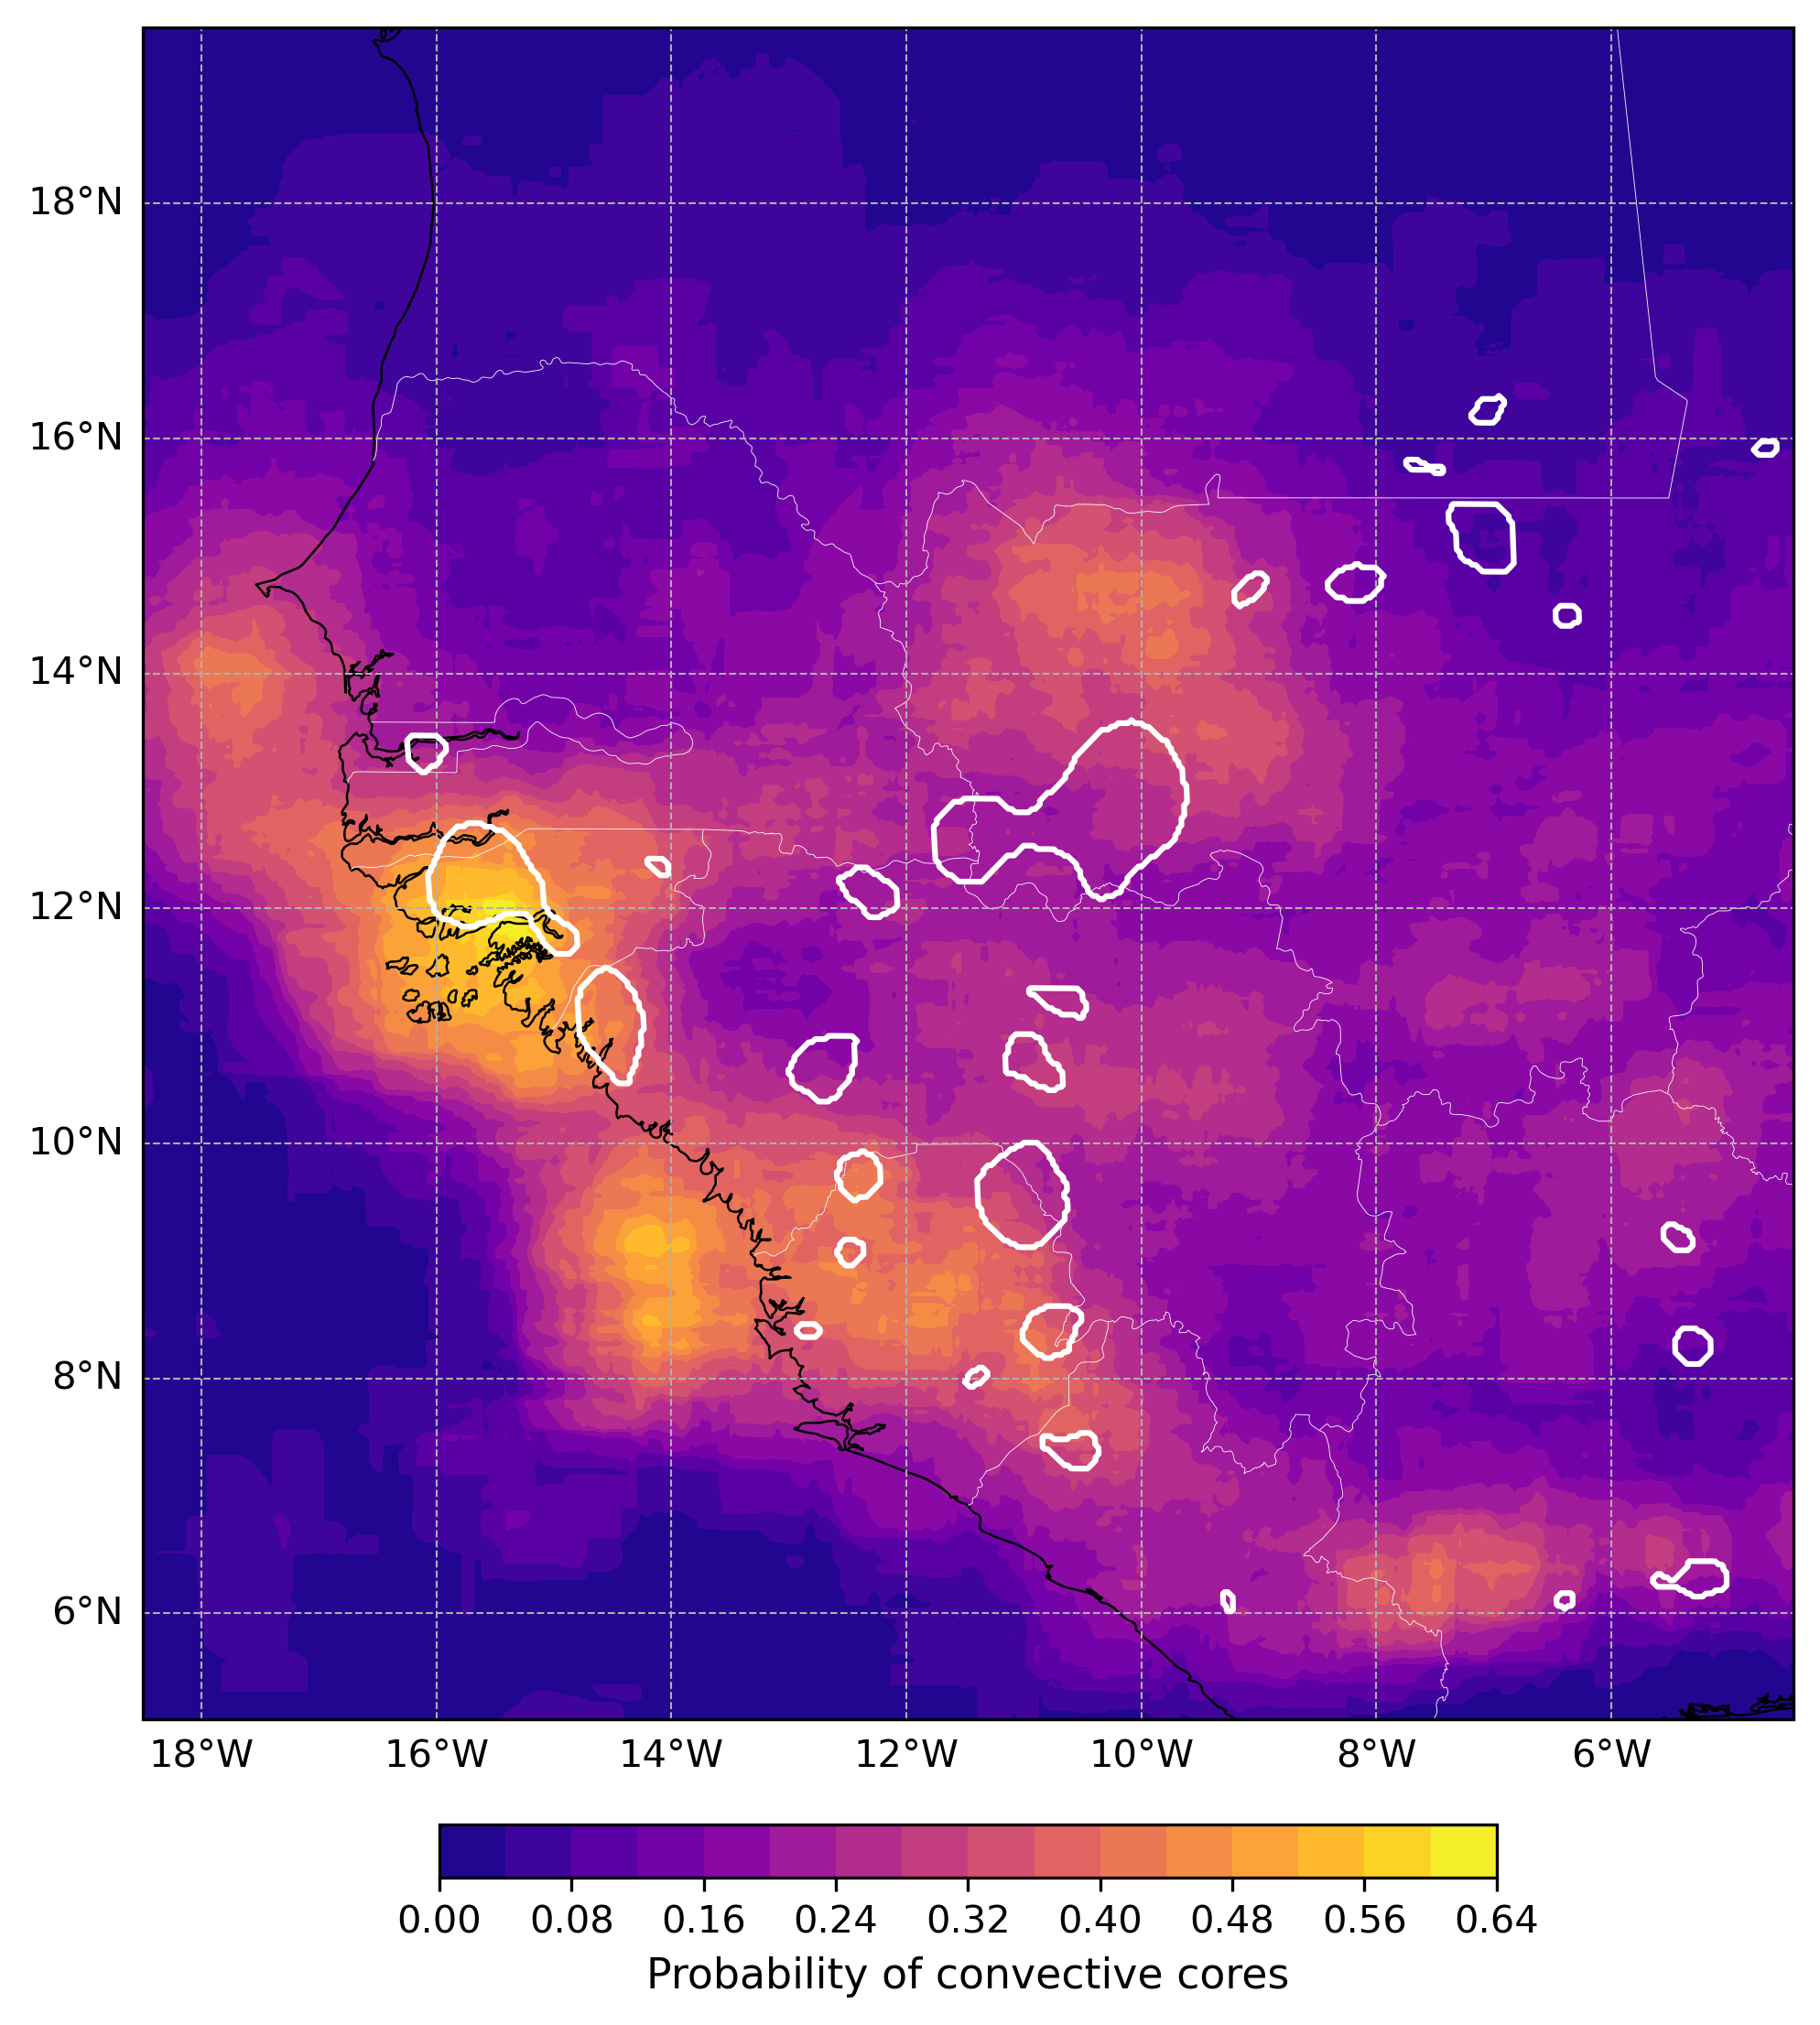

In [84]:
# create figure and axis
fig, ax = plt.subplots(
    1, 1, figsize=(8, 8),
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=300
)

# set extent
ax.set_extent(
    [
        DISPLAY_LON_MIN,
        DISPLAY_LON_MAX,
        DISPLAY_LAT_MIN,
        DISPLAY_LAT_MAX
    ],
    crs=ccrs.PlateCarree()
)

# base map features
ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='white', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.6)
ax.add_feature(cfeature.BORDERS, edgecolor='white', linewidth=0.2)

# western sahel gridlines
gl = ax.gridlines(
    draw_labels=True,
    alpha=1,
    linestyle='--',
    linewidth=0.5
)
gl.top_labels = False
gl.right_labels = False

# filled contours for nflics probability
im = ax.contourf(
    lons_crop_512,
    lats_crop_512,
    nflics_crop_512,
    cmap='plasma',
    levels=20,
    vmin=0,
    vmax=np.max(nflics),
    transform=ccrs.PlateCarree(),
    zorder=1
)

# smooth binary ground truth
gt_smooth = gaussian_filter(ground_truth_t1.astype(float), sigma=0.4)

# red outline of observed storms
ax.contour(
    lons,
    lats,
    gt_smooth,
    levels=[0.5],
    colors='white',
    linewidths=1.5,
    transform=ccrs.PlateCarree(),
    zorder=5
)

# colourbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation='horizontal',
    shrink=0.5,
    pad=0.05
)
cbar.set_label('Probability of convective cores', fontsize=11)

# title
plt.tight_layout()
plt.show()


In [85]:
lats

array([[ 5.0846257,  5.0844684,  5.0842857, ...,  5.033218 ,  5.033199 ,
         5.033134 ],
       [ 5.112226 ,  5.112068 ,  5.1118836, ...,  5.060531 ,  5.060511 ,
         5.060447 ],
       [ 5.1398506,  5.139684 ,  5.1394997, ...,  5.087871 ,  5.0878444,
         5.0877857],
       ...,
       [19.640684 , 19.639977 , 19.63917  , ..., 19.417618 , 19.417496 ,
        19.417246 ],
       [19.670902 , 19.670141 , 19.669373 , ..., 19.44733  , 19.447262 ,
        19.44701  ],
       [19.701021 , 19.700323 , 19.69949  , ..., 19.477114 , 19.477043 ,
        19.476782 ]], dtype=float32)

In [86]:
lats_crop_512

array([[ 5.05247739,  5.05247739,  5.05247739, ...,  5.05247739,
         5.05247739,  5.05247739],
       [ 5.08109804,  5.08109804,  5.08109804, ...,  5.08109804,
         5.08109804,  5.08109804],
       [ 5.10971869,  5.10971869,  5.10971869, ...,  5.10971869,
         5.10971869,  5.10971869],
       ...,
       [19.62038684, 19.62038684, 19.62038684, ..., 19.62038684,
        19.62038684, 19.62038684],
       [19.64900749, 19.64900749, 19.64900749, ..., 19.64900749,
        19.64900749, 19.64900749],
       [19.67762814, 19.67762814, 19.67762814, ..., 19.67762814,
        19.67762814, 19.67762814]])

In [87]:
lons

array([[-18.51094  , -18.48153  , -18.452026 , ...,  -4.229808 ,
         -4.20263  ,  -4.1754155],
       [-18.511904 , -18.482492 , -18.452988 , ...,  -4.230013 ,
         -4.2028337,  -4.1756186],
       [-18.51296  , -18.483522 , -18.454016 , ...,  -4.230239 ,
         -4.2030525,  -4.175842 ],
       ...,
       [-19.822138 , -19.790308 , -19.758379 , ...,  -4.5086794,
         -4.479689 ,  -4.450669 ],
       [-19.82672  , -19.794827 , -19.76293  , ...,  -4.5096273,
         -4.480645 ,  -4.4516177],
       [-19.831186 , -19.799355 , -19.767384 , ...,  -4.5105925,
         -4.481603 ,  -4.4525676]], dtype=float32)

In [88]:
lons_crop_512

array([[-19.81900263, -19.78843212, -19.75786161, ...,  -4.25861201,
         -4.2280415 ,  -4.19747099],
       [-19.81900263, -19.78843212, -19.75786161, ...,  -4.25861201,
         -4.2280415 ,  -4.19747099],
       [-19.81900263, -19.78843212, -19.75786161, ...,  -4.25861201,
         -4.2280415 ,  -4.19747099],
       ...,
       [-19.81900263, -19.78843212, -19.75786161, ...,  -4.25861201,
         -4.2280415 ,  -4.19747099],
       [-19.81900263, -19.78843212, -19.75786161, ...,  -4.25861201,
         -4.2280415 ,  -4.19747099],
       [-19.81900263, -19.78843212, -19.75786161, ...,  -4.25861201,
         -4.2280415 ,  -4.19747099]])

In [89]:
lead_times = [1, 3, 6]
nflics_512_frame = {}

# target size
H, W = 512, 512

for lt in lead_times:
    nflics = load_NFLICS_nowcast(year, month, day, hour, minute, lt)

    nflics[nflics <= 0] = 0.0
    nflics = nflics / 100
    nflics = np.clip(nflics, 0.0, 1.0)

    nflics_crop = nflics[row_min:row_max+1, col_min:col_max+1]

    h, w = nflics_crop.shape
    zoom_h = H / h
    zoom_w = W / w

    nflics_512_frame[lt] = zoom(nflics_crop, (zoom_h, zoom_w), order=1)

In [90]:
print(row_min, row_max, col_min, col_max)

249 764 101 597
